In [1]:
import pandas as pd
from rapidfuzz import process, fuzz
import unidecode
import math
from statsbombpy import sb
from datetime import datetime, date, timedelta
import soccerdata as sd
import numpy as np
from shapely.geometry import Point
from shapely.geometry.polygon import Polygon
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, roc_auc_score, f1_score, log_loss, brier_score_loss, mean_absolute_error, accuracy_score
from selenium import webdriver
from IPython.display import clear_output
import shap


[04/23/26 12:00:53] INFO     No custom team name replacements found. You can configure these in       ]8;id=621393;file://c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\soccerdata\_config.py\_config.py]8;;\:]8;id=87828;file://c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\soccerdata\_config.py#92\92]8;;\
                             C:\Users\andre\soccerdata\config\teamname_replacements.json.                          

                    INFO     No custom league dict found. You can configure additional leagues in    ]8;id=733127;file://c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\soccerdata\_config.py\_config.py]8;;\:]8;id=586646;file://c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\soccerdata\_config.py#198\198]8;;\
                             C:\Users\andre\soccerdata\config\league_dict.json.                                    

In [2]:
def getShotmap(matchId, driver):
    # collects the base shotmap from SofaScore

    base_url = "https://www.sofascore.com/api/v1/event/"

    url = base_url + str(matchId) + "/shotmap"

    data = driver.execute_async_script("""
    const url = arguments[0];
    const callback = arguments[arguments.length - 1];

    fetch(url)
      .then(r => r.json())
      .then(data => callback(data));
    """, url)
    shotmap = data['shotmap']
    
    # creates a DataFrame from the SofaScore shotmap with the most useful features

    players = []
    homes = []
    situations = []
    bodyParts = []
    minutes = []
    x = []
    y = []
    for shot in shotmap:
        player = shot['player']['name']
        isHome = shot['isHome']
        situation = shot['situation']
        bodyPart = shot['bodyPart']
        minute = shot['time']
        shotX = shot['playerCoordinates']['x']
        shotY = shot['playerCoordinates']['y']
        players.append(player)
        homes.append(isHome)
        situations.append(situation)
        bodyParts.append(bodyPart)
        minutes.append(minute)
        x.append(shotX)
        y.append(shotY)

    df = pd.DataFrame()
    df['player'] = players
    df['isHome'] = homes
    df['situation'] = situations
    df['bodyPart'] = bodyParts
    df['minute'] = minutes
    df['x'] = x
    df['y'] = y
    df = df.sort_values(by=['minute']).reset_index()
    df = df.drop(columns=['index'])
    return df

In [3]:
def getLineups(matchId, driver):
    # collects the lineups from SofaScore

    base_url = "https://www.sofascore.com/api/v1/event/"

    url = base_url + str(matchId) + "/lineups"

    data = driver.execute_async_script("""
    const url = arguments[0];
    const callback = arguments[arguments.length - 1];

    fetch(url)
      .then(r => r.json())
      .then(data => callback(data));
    """, url)

    homeLineup = pd.DataFrame(data['home']['players'])
    awayLineup = pd.DataFrame(data['away']['players'])

    # creates a DataFrame from the SofaScore lineups with the most useful features
    
    homePlayers = []
    homePositions = []
    homeRoles = []
    homeIds = []
    awayPlayers = []
    awayPositions = []
    awayRoles = []
    awayIds = []
    for i in homeLineup.index:
        player = homeLineup.loc[i]['player']['name']
        position = homeLineup.loc[i]['position']
        substitute = homeLineup.loc[i]['substitute']
        id = homeLineup.loc[i]['player']['id']
        homePlayers.append(player)
        homePositions.append(position)
        if not substitute:
            homeRoles.append('starter')
        else:
            homeRoles.append('sub')
        homeIds.append(id)

    for i in awayLineup.index:
        player = awayLineup.loc[i]['player']['name']
        position = awayLineup.loc[i]['position']
        substitute = awayLineup.loc[i]['substitute']
        id = awayLineup.loc[i]['player']['id']
        awayPlayers.append(player)
        awayPositions.append(position)
        if not substitute:
            awayRoles.append('starter')
        else:
            awayRoles.append('sub')
        awayIds.append(id)

    homeDf = pd.DataFrame()
    homeDf['name'] = homePlayers
    homeDf['position'] = homePositions
    homeDf['role'] = homeRoles
    homeDf['id'] = homeIds

    awayDf = pd.DataFrame()
    awayDf['name'] = awayPlayers
    awayDf['position'] = awayPositions
    awayDf['role'] = awayRoles
    awayDf['id'] = awayIds
    return homeDf, awayDf

In [4]:
def getPlayerFoot(playerId, driver):
    # collects the player info to obtain his preferred foot

    base_url = "https://www.sofascore.com/api/v1/player/"

    url = base_url + str(playerId)

    data = driver.execute_async_script("""
    const url = arguments[0];
    const callback = arguments[arguments.length - 1];

    fetch(url)
      .then(r => r.json())
      .then(data => callback(data));
    """, url)

    # returns the preferred foot
    if data['player']['preferredFoot'] == 'Left':
        return "LeftFoot"
    elif data['player']['preferredFoot'] == 'Right':
        return "RightFoot"
    else:
        return "BothFeet"
    return 

In [5]:
def find_best_match(name, names_list, threshold=75):
    # finds the best matching among a list of players
    matching, score, _ = process.extractOne(unidecode.unidecode(name), names_list, scorer=fuzz.token_set_ratio)
    if score >= threshold:
      return matching
    return None

In [6]:
def getLostPlayerStatsbomb(lostName):
  # opens the lost names file to search for the lost player
  
  with open('utility/lostStatsbomb.csv', 'r', encoding='utf-8') as f:
    sfPlayerIdsDF = pd.read_csv(f)
  sfPlayerIdsDF["player_norm"] = sfPlayerIdsDF["player"].apply(lambda x: unidecode.unidecode(str(x)))
  if lostName in sfPlayerIdsDF["player_norm"].values:
    fotmobName = sfPlayerIdsDF.loc[sfPlayerIdsDF["player_norm"] == lostName, "fotmobName"].values[0]
    return fotmobName
  return 0

In [7]:
def getEloRating(team, dateString, debug=False):
    # corrects differences between names
    if team == "Manchester City":
      team = "Man City"
    if team == "Manchester United":
      team = "Man United"
    elif team == "Nottingham Forest":
      team = "Forest"
    elif team == "West Ham United":
      team = "West Ham"
    elif(team == "Hellas Verona"):
      team = "Verona"
    elif(team == "Brighton & Hove Albion"):
      team = "Brighton"
    elif(team == "Luton Town"):
      team = "Luton"
    elif(team == "Newcastle United"):
      team = "Newcastle"
    elif(team == "Tottenham Hotspur"):
      team = "Tottenham"
    elif(team == "Wolverhampton"):
      team = "Wolves"
    elif(team == "Wolverhampton Wanderers"):
      team = "Wolves"
    elif (team == "U.C Sampdoria"):
      team = "Sampdoria"
    elif (team == "Leeds United"):
      team = "Leeds"
    elif (team == "Leicester City"):
      team = "Leicester"
    elif (team == "AFC Bournemouth"):
      team = "Bournemouth"
    elif (team == "Ipswich Town"):
      team = "Ipswich"
    elif (team == "Athletic Club"):
      team = "Bilbao"
    elif (team == "Real Sociedad"):
      team = "Sociedad"
    elif (team == "Girona FC"):
      team = "Girona"
    elif (team == "Celta Vigo"):
      team = "Celta"
    elif (team == "Real Betis"):
      team = "Betis"
    elif (team == "Atlético Madrid"):
      team = "Atletico"
    elif(team == "Deportivo Alavés"):
      team = "Alaves"
    elif (team == "Real Valladolid"):
      team = "Valladolid"
    elif (team == "SV Werder Bremen"):
      team = "Werder"
    elif (team == "Werder Bremen"):
      team = "Werder"
    elif (team == "FC Bayern München"):
      team = "Bayern"
    elif (team == "Bayern Munich"):
      team = "Bayern"
    elif (team == "Hamburger SV"):
      team = "Hamburg"
    elif (team == "Schalke 04"):
      team = "Schalke"
    elif (team == "Hannover 96"):
      team = "Hannover"
    elif (team == "Bayer 04 Leverkusen"):
      team = "Leverkusen"
    elif (team == "Bayer Leverkusen"):
      team = "Leverkusen"
    elif (team == "Borussia Dortmund"):
      team = "Dortmund"
    elif (team == "1. FC Köln"):
      team = "Koeln"
    elif (team == "FC Köln"):
      team = "Koeln"
    elif (team == "FC Augsburg"):
      team = "Augsburg"
    elif (team == "Borussia M'gladbach"):
      team = "Gladbach"
    elif (team == "Borussia Mönchengladbach"):
      team = "Gladbach"
    elif (team == "TSG Hoffenheim"):
      team = "Hoffenheim"
    elif (team == "SC Freiburg"):
      team = "Freiburg"
    elif (team == "VfB Stuttgart"):
      team = "Stuttgart"
    elif (team == "VfL Bochum 1848"):
      team = "Bochum"
    elif (team == "VfL Wolfsburg"):
      team = "Wolfsburg"
    elif (team == "1. FC Heidenheim"):
      team = "Heidenheim"
    elif (team == "FC Heidenheim"):
      team = "Heidenheim"
    elif (team == "1. FC Union Berlin"):
      team = "Union Berlin"
    elif (team == "Hertha Berlin"):
      team = "Hertha"
    elif (team == "1. FSV Mainz 05"):
      team = "Mainz"
    elif (team == "FSV Mainz 05"):
      team = "Mainz"
    elif (team == "Eintracht Frankfurt"):
      team = "Frankfurt"
    elif (team == "Darmstadt 98"):
      team = "Darmstadt"
    elif (team == "Hertha BSC"):
      team = "Hertha"
    elif (team == "FC Schalke 04"):
      team = "Schalke"
    elif (team == "Holstein Kiel"):
      team = "Holstein"
    elif (team == "FC St. Pauli"):
      team = "St Pauli"
    elif (team == "Paris Saint-Germain"):
      team = "Paris SG"
    elif (team == "AS Monaco"):
      team = "Monaco"
    elif (team == "Stade Brestois"):
      team = "Brest"
    elif (team == "Olympique de Marseille"):
      team = "Marseille"
    elif (team == "Stade de Reims"):
      team = "Reims"
    elif (team == "RC Lens"):
      team = "Lens"
    elif (team == "RC Strasbourg"):
      team = "Strasbourg"
    elif (team == "Stade Rennais"):
      team = "Rennes"
    elif (team == "Olympique Lyonnais"):
      team = "Lyon"
    elif (team == "Clermont Foot"):
      team = "Clermont"
    elif (team == "AS Roma"):
      team = "Roma"
    elif (team == "AC Milan"):
      team = "Milan"
    elif (team == "Inter Milan"):
      team = "Inter"
    elif (team == "Swansea City"):
      team = "Swansea"
    elif (team == "West Bromwich Albion"):
      team = "West Brom"
    elif (team == "Norwich City"):
      team = "Norwich"
    elif (team == "Stoke City"):
      team = "Stoke"
    elif (team == "Sporting Gijón"):
      team = "Gijon"
    elif (team == "RC Deportivo La Coruña"):
      team = "Depor"
    elif (team == "Atletico Madrid"):
      team = "Atletico"
    elif (team == "Levante UD"):
      team = "Levante"
    elif (team == "Real Betis"):
      team = "Betis"
    elif (team == "Gazélec Ajaccio"):
      team = "Troyes"
    elif (team == "OGC Nice"):
      team = "Nice"


    # obtains the match's date
    year, month, day = dateString.split("-")
    year = int(year)
    month = int(month)
    day = int(day)
    if debug:
      print("Elo Rating: Reading Team History...")
    # obtains the team's elo history and looks for the most recent value within 31 days
    dfElo = elo.read_team_history(team)
    if debug:
      print("Elo Rating: Finding Elo...")
    for i in range(0, 31):

        if(len(dfElo[(dfElo.index.year == year) & (dfElo.index.month == month) & (dfElo.index.day == (day-i))]) == 0):
            eloTeam = dfElo[(dfElo.index.year == year) & (dfElo.index.month == month)].reset_index()
            # print(team + " Elo Date: " + str(eloTeam.loc[0]['from']).split(" ", 1)[0])
            break
        # else:
            # eloTeam = dfElo[(dfElo.index.year == year) & (dfElo.index.month == month) & (dfElo.index.day == day)].reset_index()

    return int(eloTeam.loc[0]['elo'])

In [8]:
def convertXY(x, y):
  # converts coordinates into distance and angle
  dx = 120 - x
  dy = 40 - y
  distance = math.hypot(dx, dy)
  angle_rad = math.atan2(abs(dy), dx)
  angle_deg = math.degrees(angle_rad)
  return int(distance), int(angle_deg)

In [9]:
def find_values(competition, season):
  # given a competition name and a season, finds the competition id and the season id in StatsBomb
  comp = sb.competitions()
  comp = comp.sort_values(by=['season_name'], ascending=False)
  
  for i in comp.index:
    if comp.loc[i]['competition_name'] == competition and comp.loc[i]['season_name'] == season:
      competition_id = comp.loc[i]['competition_id']
      season_id = comp.loc[i]['season_id']
      return competition_id, season_id

In [10]:
def findVersionByDate(versions, dateObject):
  # finds the correct SoFIFA version, based on a given date
  versions = versions.iloc[::-1].reset_index()
  mask = pd.to_datetime(versions['update'], errors='coerce').notna()

  # filters the dataframe
  versions = versions[mask]
  limit = dateObject + timedelta(days=30)
  for i in versions.index:
    # versionDateObject = datetime.strptime(versions.loc[i]['update'], '%b %d, %Y').date()
    versionDateObject = pd.to_datetime(
        versions.loc[i]['update'],
        dayfirst=True,
        errors='coerce'
    )

    if pd.isna(versionDateObject):
        continue

    versionDateObject = versionDateObject.date()


    if dateObject <= versionDateObject <= limit:
      print("Version Found: " + str(versions.loc[i]['version_id']))
      version = versions.loc[i]['version_id']
      if version == 160002:
        print("Version Changed: 160003")
        return 160003
      if version == 160020:
        print("Version Changed: 160023")
        return 160023
      if version == 160038:
        print("Version Changed: 160039")
        return 160039
      return version
  limit = dateObject - timedelta(days=30)
  for i in versions.index:
    # versionDateObject = datetime.strptime(versions.loc[i]['update'], '%b %d, %Y').date()
    versionDateObject = pd.to_datetime(
        versions.loc[i]['update'],
        dayfirst=True,
        errors='coerce'
    )

    if pd.isna(versionDateObject):
        continue

    versionDateObject = versionDateObject.date()


    if limit <= versionDateObject <= dateObject:
      print("Version Found: " + str(versions.loc[i]['version_id']))
      version = versions.loc[i]['version_id']
      if version == 160002:
        print("Version Changed: 160003")
        return 160003
      if version == 160020:
        print("Version Changed: 160023")
        return 160023
      if version == 160038:
        print("Version Changed: 160039")
        return 160039
      return version
  print("Version Not Found")

In [11]:
def getShotRating(sf, playerId, debug=False):
  # given a SoFIFA version and a player id, obtains his stats and calculates the shooting rating
  playerId = int(playerId)
  if debug:
    print("Player ID:", playerId)
    print("Getting Shot Rating: Getting Ratings Dataframe...")
  dfRatings = sf.read_player_ratings(player=playerId).reset_index()
  if debug:
    print("Getting Shot Rating: Getting Stats...")
  stats = dfRatings.loc[0]
  finishing = stats['finishing']
  volleys = stats['volleys']
  shotPower = stats['shotpower']
  longShots = stats['longshots']
  penalties = stats['penalties']
  if debug:
    print("Getting Shot Rating: Computing Stats...")
  shotRating = (int(finishing)*0.45) + (int(shotPower)*0.2) + (int(longShots)*0.2) + (int(volleys)*0.1) + (int(penalties)*0.05)
  if debug:
    print("Getting Shot Rating: Returning Rating...")
  return math.floor(shotRating)

In [12]:
def getLostPlayerCSV(sofifaSingle, lostName, debug=False):
  # given a SoFIFA version and a name for a lost player, searches for the player in the lost players csv file and obtains his rating
  print(lostName)
  with open('utility/lostPlayers.csv', 'r', encoding='utf-8') as f:
    sfPlayerIdsDF = pd.read_csv(f)
  sfPlayerIdsDF["player_norm"] = sfPlayerIdsDF["player"].apply(lambda x: unidecode.unidecode(str(x)))
  if lostName in sfPlayerIdsDF["player_norm"].values:
    print("found")
    sfPlayerId = sfPlayerIdsDF.loc[sfPlayerIdsDF["player_norm"] == lostName, "playerID"].values[0]
    print("getting shot rating")
    return getShotRating(sofifaSingle, sfPlayerId, debug=debug)
  return 0

In [13]:
def find_best_player(playerName, df):
  # finds best matching in a players list
  names = [unidecode.unidecode(df.loc[j]['player']) for j in df.index]
  matching = process.extractOne(
      playerName,
      names,
      scorer=fuzz.token_set_ratio  # <-- confronto per token
  )
  if matching and matching[1] >= 80:
      idx = names.index(matching[0])
      return df.index[idx]
  return None

In [14]:
def getPlayerRating(playerName, home, pHome, pAway, sofifaSingle, game, fifaPlayers, debug=False):
  # finds the best matching for the player in the lineups and obtains his shot rating
  found = False
  playerName = unidecode.unidecode(playerName)
  if home == True:
    matching = find_best_player(playerName, pHome)
    if matching:
      found=True
      rating = getShotRating(sofifaSingle,matching, debug=debug)
      return rating
  else:
    matching = find_best_player(playerName, pAway)
    if matching:
      found=True
      rating = getShotRating(sofifaSingle,matching, debug=debug)
      return rating
  if not found:
    matching = find_best_player(playerName, fifaPlayers)
    if matching:
      found=True
      rating = getShotRating(sofifaSingle,matching, debug=debug)
      return rating
    if not found:
      rating = getLostPlayerCSV(sofifaSingle, playerName, debug=debug)
      if rating != 0:
        return rating
      else:
        print("Not Found:", playerName)
        f = open("utility/notFound.txt", "a")
        f.write(playerName + ", Date: " + str(game['date']) + "\n")
        f.close()
        return -100

In [15]:
def getLostKeeperCSV(sofifaSingle, lostName):
  # given a SoFIFA version and a lost goalkeeper, looks into the lost keepers file and obtains his rating
  sfPlayerIdsDF = pd.read_csv('utility/lostKeepers.csv')
  sfPlayerIdsDF["player_norm"] = sfPlayerIdsDF["player"].apply(lambda x: unidecode.unidecode(str(x)))
  if lostName in sfPlayerIdsDF["player_norm"].values:
    sfPlayerId = sfPlayerIdsDF.loc[sfPlayerIdsDF["player_norm"] == lostName, "playerID"].values[0]
    rating = sofifaSingle.read_player_ratings(player=int(sfPlayerId))['overallrating'].iloc[0]
    return rating
  return 0

In [16]:
def getKeeperRating(playerName, home, pHome, pAway, sofifaSingle, game, fifaPlayers):
  # looks for the player in the lineups and obtains his rating
  found = False
  playerName = unidecode.unidecode(playerName)
  if home == True:
    matching = find_best_player(playerName, pHome)
    if matching:
      found=True
      rating = sofifaSingle.read_player_ratings(team=game['home_team'], player=int(matching))['overallrating'].iloc[0]
      return rating
  else:
    matching = find_best_player(playerName, pAway)
    if matching:
      found=True
      rating = sofifaSingle.read_player_ratings(team=game['away_team'], player=int(matching))['overallrating'].iloc[0]
      return rating
  if not found:


    matching = find_best_player(playerName, fifaPlayers)
    if matching:
      found=True
      rating = sofifaSingle.read_player_ratings(player=int(matching))['overallrating'].iloc[0]
      return rating
    if not found:
      rating = getLostKeeperCSV(sofifaSingle, playerName)
      if rating != 0:
        return rating
      else:
        print("Not Found:", playerName)
        f = open("utility/notFound.txt", "a")
        f.write(playerName + ", Date: " + str(game['date']) + "\n")
        f.close()
        return -100

In [17]:
def findSofaGame(gameSb, scheduleSs):
    # given a StatsBomb game object, finds the SofaScore game object
    print(gameSb['home_team'], gameSb['away_team'])
    home_team = gameSb['home_team']
    away_team = gameSb['away_team']

    if home_team == "FC Köln":
        home_team = "1. FC Köln"
    elif home_team == "Bayern Munich":
        home_team = "Bayern München"
    elif home_team == "Darmstadt 98":
        home_team = "Darmstadt"
    elif home_team == "FSV Mainz 05":
        home_team = "Mainz 05"
    elif home_team == "Hertha Berlin":
        home_team = "Hertha BSC"
    elif home_team == "AS Roma":
        home_team = "Roma"
    elif home_team == "AC Milan":
        home_team = "Milan"
    elif home_team == "Inter Milan":
        home_team = "Inter"
    elif home_team == "Chievo":
        home_team = "ChievoVerona"
    elif home_team == "Sporting Gijón":
        home_team = "Sporting Gijon"
    elif home_team == "RC Deportivo La Coruña":
        home_team = "Deportivo La Coruna"
    elif home_team == "Atlético Madrid":
        home_team = "Atletico Madrid"
    elif home_team == "Levante UD":
        home_team = "Levante"
    elif home_team == "Málaga":
        home_team = "Malaga"
    elif home_team == "Bastia":
        home_team = "SC Bastia"
    elif home_team == "Gazélec Ajaccio":
        home_team = "GFC Ajaccio"
    elif home_team == "OGC Nice":
        home_team = "Nice"
    elif home_team == "AS Monaco":
        home_team = "Monaco"
    elif home_team == "Saint-Étienne":
        home_team = "Saint-Etienne"
    elif home_team == "Stade de Reims":
        home_team = "Reims"




    if away_team == "FC Köln":
        away_team = "1. FC Köln"
    elif away_team == "Bayern Munich":
        away_team = "Bayern München"
    elif away_team == "Darmstadt 98":
        away_team = "Darmstadt"
    elif away_team == "FSV Mainz 05":
        away_team = "Mainz 05"
    elif away_team == "Hertha Berlin":
        away_team = "Hertha BSC"
    elif away_team == "AS Roma":
        away_team = "Roma"
    elif away_team == "AC Milan":
        away_team = "Milan"
    elif away_team == "Chievo":
        away_team = "ChievoVerona"
    elif away_team == "Inter Milan":
        away_team = "Inter"
    elif away_team == "Sporting Gijón":
        away_team = "Sporting Gijon"
    elif away_team == "RC Deportivo La Coruña":
        away_team = "Deportivo La Coruna"
    elif away_team == "Atlético Madrid":
        away_team = "Atletico Madrid"
    elif away_team == "Levante UD":
        away_team = "Levante"
    elif away_team == "Málaga":
        away_team = "Malaga"
    elif away_team == "Bastia":
        away_team = "SC Bastia"
    elif away_team == "Gazélec Ajaccio":
        away_team = "GFC Ajaccio"
    elif away_team == "OGC Nice":
        away_team = "Nice"
    elif away_team == "AS Monaco":
        away_team = "Monaco"
    elif away_team == "Saint-Étienne":
        away_team = "Saint-Etienne"
    elif away_team == "Stade de Reims":
        away_team = "Reims"
    
    for i in scheduleSs.index:
        gameSs = scheduleSs.loc[i]
        if home_team == gameSs['home_team'] and away_team == gameSs['away_team']:
            return gameSs


In [18]:
def checkNames(team_sofifa):
    # checks differences between team names from SoFIFA and other sources
    if team_sofifa == "Bayer Leverkusen":
        team_sofifa = "Bayer 04 Leverkusen"
    if team_sofifa == "Darmstadt 98":
        team_sofifa = "SV Darmstadt 98"
    if team_sofifa == "Bayern Munich":
        # team_sofifa = "FC Bayern München"
        team_sofifa = 'FC Bayern MÃ¼nchen'
    if team_sofifa == "FC Bayern München":
        team_sofifa = 'FC Bayern MÃ¼nchen'
    if team_sofifa == "FC Heidenheim":
        team_sofifa = "1. FC Heidenheim 1846"
    if team_sofifa == "FC Heidenheim":
        team_sofifa = "1. FC Heidenheim 1846"
    if team_sofifa == "FSV Mainz 05":
        team_sofifa = "1. FSV Mainz 05"
    if team_sofifa == "FC Köln":
        # team_sofifa = "1. FC Köln"
        team_sofifa = '1. FC KÃ¶ln'
    if team_sofifa == "Wolfsburg":
        team_sofifa = "VfL Wolfsburg"
    if team_sofifa == "Augsburg":
        team_sofifa = "FC Augsburg"
    if team_sofifa == "Bochum":
        team_sofifa = 'VfL Bochum 1848'
    if team_sofifa == "Freiburg":
        team_sofifa = "SC Freiburg"
    if team_sofifa == "Hertha Berlin":
        team_sofifa = "Hertha BSC"
    if team_sofifa == "Schalke 04":
        team_sofifa = "FC Schalke 04"
    if team_sofifa == "Ingolstadt":
        team_sofifa = "FC Ingolstadt 04"
    if team_sofifa == "Hoffenheim":
        team_sofifa = 'TSG 1899 Hoffenheim'
    if team_sofifa == "Union Berlin":
        team_sofifa = "1. FC Union Berlin"
    if team_sofifa == "Werder Bremen":
        team_sofifa = "SV Werder Bremen"
    if team_sofifa == "AS Roma":
        team_sofifa = "Roma"
    if team_sofifa == "Hellas Verona":
        team_sofifa = "Hellas Verona FC"
    if team_sofifa == "Inter Milan":
        team_sofifa = "Inter"
    if team_sofifa == "Palermo":
        team_sofifa = "Palermo FC"
    if team_sofifa == "Chievo":
        team_sofifa = "AC ChievoVerona"
    if team_sofifa == "Sporting Gijón":
        # team_sofifa = "Real Sporting de Gijón"
        team_sofifa = 'Real Sporting de GijÃ³n'
    if team_sofifa == "Valencia":
        team_sofifa = "Valencia CF"
    if team_sofifa == "RC Deportivo La Coruña":
        # team_sofifa = "RC Deportivo de La Coruña"
        team_sofifa = 'RC Deportivo de La CoruÃ±a'
    if team_sofifa == "Espanyol":
        team_sofifa = "RCD Espanyol"
    if team_sofifa == "Getafe":
        team_sofifa = "Getafe CF"
    if team_sofifa == "Las Palmas":
        team_sofifa = "UD Las Palmas"
    if team_sofifa == "Celta Vigo":
        team_sofifa = "RC Celta"
    if team_sofifa == "Real Betis":
        # team_sofifa = "Real Betis Balompié"
        team_sofifa = 'Real Betis BalompiÃ©'
    if team_sofifa == "Villarreal":
        team_sofifa = "Villarreal CF"
    if team_sofifa == "Granada":
        team_sofifa = "Granada CF"
    if team_sofifa == "Eibar":
        team_sofifa = "SD Eibar"
    if team_sofifa == "Málaga":
        # team_sofifa = "Málaga CF"
        team_sofifa = 'MÃ¡laga CF'
    if team_sofifa == "Sevilla":
        team_sofifa = "Sevilla FC"
    if team_sofifa == "Barcelona":
        team_sofifa = "FC Barcelona"
    if team_sofifa == "Marseille":
        team_sofifa = "Olympique de Marseille"
    if team_sofifa == "Caen":
        team_sofifa = "Stade Malherbe Caen"
    if team_sofifa == "Bastia":
        team_sofifa = "Sporting Club Bastia"
    if team_sofifa == "Rennes":
        team_sofifa = "Stade Rennais FC"
    if team_sofifa == "Troyes":
        team_sofifa = "ESTAC Troyes"
    if team_sofifa == "Gazélec Ajaccio":
        team_sofifa = "GFC Ajaccio"
    if team_sofifa == "Nantes":
        team_sofifa = "FC Nantes"
    if team_sofifa == "Guingamp":
        team_sofifa = "En Avant Guingamp"
    if team_sofifa == "Toulouse":
        team_sofifa = "Toulouse FC"
    if team_sofifa == "Saint-Étienne":
        # team_sofifa = "AS Saint-Étienne"
        team_sofifa = 'AS Saint-Ã\x89tienne'
    if team_sofifa == "Lyon":
        team_sofifa = "Olympique Lyonnais"
    if team_sofifa == "Lorient":
        team_sofifa = "FC Lorient"
    if team_sofifa == "Lille":
        team_sofifa = "Lille OSC"
    if team_sofifa == "Montpellier":
        team_sofifa = "Montpellier HSC"
    if team_sofifa == "Angers":
        team_sofifa = "Angers SCO"
    if team_sofifa == "Bordeaux":
        team_sofifa = "FC Girondins de Bordeaux"
    if team_sofifa == "Borussia Mönchengladbach":
        team_sofifa = 'Borussia MÃ¶nchengladbach'
    if team_sofifa == "Atlético Madrid":
        team_sofifa = 'AtlÃ©tico Madrid'
    
    return team_sofifa

In [19]:
def getBaseShotmap(game, scheduleSs, index, league, filename, driver=None, debug=False, write=False):
    # obtains the base shotmap from a game object
    if debug:
        print("getBaseShotmap: Finding SofaScore Game...")
    # finds the SofaScore game from a StatsBomb game object
    gameSs = findSofaGame(game, scheduleSs)
    if debug:
        print(gameSs)
    if debug:
        print("getBaseShotmap: Getting Lineups...")
    # obtains the lineups from the SofaScore object
    hl, al = getLineups(gameSs['game_id'], driver)

    dates = []
    homeTeams = []
    awayTeams = []
    x = []
    y = []
    bodyParts = []
    eloTeams = []
    eloOpponents = []
    opponents = []
    # obtains info about the match and the involved teams
    match_id = game['match_id']
    match_date = game['match_date']
    home_team = game['home_team']
    away_team = game['away_team']

    home_team_sofifa = game['home_team']
    away_team_sofifa = game['away_team']

    home_team_sofifa = checkNames(home_team_sofifa)
    away_team_sofifa = checkNames(away_team_sofifa)

    print(index, game['match_week'], game['home_team'], game['away_team'])

    # collects the StatsBomb data regarding the match's shots
    events = sb.events(match_id=match_id, split=True)
    shots = events['shots']
    opponentsInConeArray = []
    minDistArray = []
    ratings = []
    keepers = []
    keeperRatings = []
    foundKeepers = []
    foundPlayers = []

    if debug:
        print("getBaseShotmap: Getting Elos...")
    # obtains elo ratings for both teams
    dateString, time = str(gameSs['date']).split(" ", 1)
    year, month, day = dateString.split("-")
    dateObject = date(int(year), int(month), int(day))
    eloHome = getEloRating(home_team, dateString, debug=debug)
    eloAway = getEloRating(away_team, dateString, debug=debug)

    if debug:
        print("getBaseShotmap: Finding Version...")
    # finds the correct SoFIFA version
    version_id = findVersionByDate(versions, dateObject)
    sofifaSingle = sd.SoFIFA(leagues=league, versions=int(version_id))
    teamNames = sofifaSingle.read_teams()
    teamNames = teamNames['team'].to_list()
    print(teamNames)
    # obtains the list of players for the specific league
    fifaPlayers = sofifaSingle.read_players()
    duplicates = fifaPlayers[fifaPlayers.duplicated('player')]
    for index in duplicates.index:
        fifaPlayers = fifaPlayers.drop(index)


    # obtains the list of players for the involved teams
    if home_team_sofifa in teamNames:
        playersHome = sofifaSingle.read_players(team=home_team_sofifa)
    else:
        print("Team " + home_team_sofifa + " Not Found")
        print(home_team_sofifa, teamNames)
        raise ValueError("Team Non Trovato")
        playersHome = fifaPlayers
    if away_team_sofifa in teamNames:
        playersAway = sofifaSingle.read_players(team=away_team_sofifa)
    else:
        print("Team " + away_team_sofifa + " Not Found")
        print(away_team_sofifa, teamNames)
        raise ValueError("Team Non Trovato")
        playersAway = fifaPlayers

    # obtains the two goalkeepers
    awayKeeper = al.reset_index().loc[0]['name']
    homeKeeper = hl.reset_index().loc[0]['name']

    if debug:
        print("getBaseShotmap: Getting Shots Stats...")
    for j in shots.index:
        # obtains ratings for player and keeper
        if shots.loc[j]['team'] == home_team:
            eloTeams.append(eloHome)
            eloOpponents.append(eloAway)
            opponents.append(away_team)
            rating = getPlayerRating(shots.loc[j]['player'], True, playersHome, playersAway, sofifaSingle, gameSs, fifaPlayers)
            ratings.append(rating)
            keepers.append(awayKeeper)
            keeperRating = getKeeperRating(awayKeeper, True, playersHome, playersAway, sofifaSingle, gameSs, fifaPlayers)
            keeperRatings.append(keeperRating)
        elif shots.loc[j]['team'] == away_team:
            eloTeams.append(eloAway)
            eloOpponents.append(eloHome)
            opponents.append(home_team)
            rating = getPlayerRating(shots.loc[j]['player'], False, playersHome, playersAway, sofifaSingle, gameSs, fifaPlayers)
            ratings.append(rating)
            keepers.append(homeKeeper)
            keeperRating = getKeeperRating(homeKeeper, False, playersHome, playersAway, sofifaSingle, gameSs, fifaPlayers)
            keeperRatings.append(keeperRating)

        # analyzes the shot frame to obtain
        dates.append(match_date)
        homeTeams.append(home_team)
        awayTeams.append(away_team)
        x.append(shots.loc[j]['location'][0])
        y.append(shots.loc[j]['location'][1])
        frame = shots.loc[j]['shot_freeze_frame']

        # if the shot is taken with feet, finds the player's fotmob id
        bodyPart = shots.loc[j]['shot_body_part']
        if bodyPart == "Left Foot" or bodyPart == "Right Foot":
            idFotmob = None
            if bodyPart == "Left Foot":
                bodyPart = "LeftFoot"
            elif bodyPart == "Right Foot":
                bodyPart = "RightFoot"
            if shots.loc[j]['team'] == home_team:
                matching = find_best_match(shots.loc[j]['player'], hl['name'])
                if not matching:
                    matching = getLostPlayerStatsbomb(unidecode.unidecode(shots.loc[j]['player']))
                if matching == 0:
                    print(hl['name'])
                    raise ValueError(str(unidecode.unidecode(shots.loc[j]['player'])) + " Non Trovato Lost Statsbomb")
                if debug:
                    print(matching)
                    print(hl['name'])
                idFotmob = hl.loc[hl['name'].apply(unidecode.unidecode) == unidecode.unidecode(matching),'id'].values[0]
            elif shots.loc[j]['team'] == away_team:
                matching = find_best_match(shots.loc[j]['player'], al['name'])
                if not matching:
                    matching = getLostPlayerStatsbomb(unidecode.unidecode(shots.loc[j]['player']))
                if matching == 0:
                    print(al['name'])
                    raise ValueError(str(unidecode.unidecode(shots.loc[j]['player'])) + " Non Trovato Lost Statsbomb")
                if debug:
                    print(matching)
                    print(al['name'])
                idFotmob = al.loc[al['name'].apply(unidecode.unidecode) == unidecode.unidecode(matching),'id'].values[0]
            if getPlayerFoot(idFotmob, driver) == bodyPart:
                bodyPart = "Strong Foot"
            else:
                bodyPart = "Weak Foot"
        # print(bodyPart)
        bodyParts.append(bodyPart)

        # analyzes the shot frame to calculate opponents in cone and minimum distance of the opposition
        minDist, opponentsInCone = 100, 0
        frame = shots.loc[j]['shot_freeze_frame']
        location = shots.loc[j]['location']
        if frame is not None and not (isinstance(frame, float) and np.isnan(frame)):
            left_post, right_post = [120, 35], [120, 45]
            polygon = Polygon([tuple(location), tuple(left_post), tuple(right_post)])
            for player in frame:
                if not player['teammate']:  # solo avversari
                    dist = np.linalg.norm(np.array(location) - np.array(player['location']))  # distanza tra pallone e avversario
                    if dist < minDist:
                        minDist = dist
                    if polygon.contains(Point(player['location'])): # se l'avversario è tra pallone e porta
                        opponentsInCone += 1
        
        opponentsInConeArray.append(opponentsInCone)
        minDistArray.append(round(minDist, 2))
    
    if debug:
        print("getBaseShotmap: Building Dataframe...")
    
    # builds the DataFrame
    shots['opponentsInCone'] = opponentsInConeArray
    shots['minDist'] = minDistArray

    shots['date'] = dates
    shots['home_team'] = homeTeams
    shots['away_team'] = awayTeams
    shots['x'] = x
    shots['y'] = y
    shots['gameIndex'] = index
    shots['body_part'] = bodyParts
    shots['eloTeam'] = eloTeams
    shots['eloOpponent'] = eloOpponents
    shots['opponent'] = opponents
    shots['rating'] = ratings
    shots['keeper'] = keepers
    shots['keeperRating'] = keeperRatings
    shots = shots[['gameIndex', 'date', 'home_team', 'away_team', 'minute', 'team', 'team_id', 'eloTeam', 'opponent', 'eloOpponent', 'player', 'player_id', 'rating', 'position', 'keeper', 'keeperRating', 'x', 'y', 'shot_statsbomb_xg', 'shot_outcome', 'play_pattern', 'body_part', 'shot_type', 'opponentsInCone', 'minDist']]

    # writes the dataframe
    if write:
        if index==0:
            shots.to_csv('datasets/sofascore/' + str(filename) + '.csv', header=True)
        else:
            shots.to_csv('datasets/sofascore/' + str(filename) + '.csv', header=False, mode='a')
    clear_output(wait=True)

    return shots


In [20]:
def getShotsDF(df):
  # refines the base shotmap
  new_df = pd.DataFrame()
  new_df['game_index'] = df['gameIndex']
  new_df['date'] = df['date']
  new_df['home_team'] = df['home_team']
  new_df['away_team'] = df['away_team']
  new_df['minute'] = df['minute']
  new_df['team'] = df['team']
  new_df['team_id'] = df['team_id']
  new_df['eloTeam'] = df['eloTeam']
  new_df['player'] = df['player']
  new_df['player_id'] = df['player_id']
  new_df['opponent'] = df['opponent']
  new_df['eloOpponent'] = df['eloOpponent']
  new_df['xg'] = df['shot_statsbomb_xg']
  new_df['body_part'] = df['body_part']
  new_df['opponentsInCone'] = df['opponentsInCone']
  new_df['minDist'] = df['minDist']
  new_df['x'] = df['x']
  new_df['y'] = df['y']

  isHome = []
  positions = []
  situations = []
  goal = []
  distances = []
  angles = []

  for i in df.index:
    shot = df.loc[i]

    # Distance Angle
    distance, angle = convertXY(shot['x'], shot['y'])
    distances.append(distance)
    angles.append(angle)

    # isHome
    if shot['team'] == shot['home_team']:
      isHome.append(True)
    elif shot['team'] == shot['away_team']:
      isHome.append(False)

    # position
    if shot['position'] == 'Goalkeeper':
      positions.append('G')
    elif shot['position'] == 'Center Back' or shot['position'] == 'Right Center Back' or shot['position'] == 'Left Center Back' or shot['position'] == 'Left Back' or shot['position'] == 'Right Back' or shot['position'] == 'Left Wing Back' or shot['position'] == 'Right Wing Back':
      positions.append('D')
    elif shot['position'] == "Center Defensive Midfield" or shot['position'] == "Left Defensive Midfield" or shot['position'] == "Right Defensive Midfield" or shot['position'] == "Left Midfield" or shot['position'] == "Right Midfield" or shot['position'] == "Left Center Midfield" or shot['position'] == "Right Center Midfield" or shot['position'] == "Center Attacking Midfield" or shot['position'] == "Left Attacking Midfield" or shot['position'] == "Right Attacking Midfield":
      positions.append('M')
    elif shot['position'] == "Left Wing" or shot['position'] == "Right Wing" or shot['position'] == "Center Forward" or shot['position'] == "Left Center Forward" or shot['position'] == "Right Center Forward":
      positions.append('F')

    # situation
    if shot['play_pattern'] == "Other":
      if shot['shot_type'] == "Open Play":
        situations.append("Regular Play")
      elif shot['shot_type'] == "Penalty":
        situations.append("Penalty")
    else:
      situations.append(shot['play_pattern'])

    # Goal - No Goal
    if shot['shot_outcome'] == "Goal":
      goal.append(1)
    else:
      goal.append(0)


  new_df['distance'] = distances
  new_df['angle'] = angles
  new_df['isHome'] = isHome
  new_df['position'] = positions
  new_df['situation'] = situations
  new_df['goal'] = goal
  new_df['rating'] = df['rating']
  new_df['keeper'] = df['keeper']
  new_df['keeperRating'] = df['keeperRating']

  hg = 0
  ag = 0
  goalDifferences = []
  gameIndex = 0
  for i in new_df.index:
    shot = new_df.loc[i]
    if shot['game_index'] != gameIndex:
      gameIndex += 1
      hg = 0
      ag = 0
    if shot['team'] == shot['home_team']:
      goalDifferences.append(hg-ag)
    elif shot['team'] == shot['away_team']:
      goalDifferences.append(ag-hg)

    if shot['goal'] == 1:
      if shot['team'] == shot['home_team']:
        hg += 1
      elif shot['team'] == shot['away_team']:
        ag += 1

  new_df['goal_difference'] = goalDifferences
  new_df = new_df[['game_index', 'date', 'home_team', 'away_team', 'minute', 'team', 'team_id', 'eloTeam', 'player', 'player_id', 'rating', 'position', 'keeper', 'keeperRating', 'opponent', 'eloOpponent', 'x', 'y', 'distance', 'angle', 'isHome', 'goal_difference', 'situation', 'body_part', 'opponentsInCone', 'minDist', 'goal', 'xg']]
  return new_df

In [21]:
def cleanDataset(df, debug=False, baseline=False, intermediate=False, old=False, best=False):
  # cleans the dataset in order to be used by models
  if debug:
    print("Clean Dataset: Preprocessing...")
  df = df.dropna(subset=['xg'])
  df = df.loc[df['position'] != 'G']
  # one-hot encoding
  x = pd.get_dummies(df, columns=['position'], prefix='position', drop_first=False) #one-hot encoding ruolo
  x = pd.get_dummies(x, columns=['situation'], prefix='situation', drop_first=False)
  x = pd.get_dummies(x, columns=['body_part'], prefix='bodyPart', drop_first=False)


  if debug:
    print("Clean Dataset: Normalizing...")
  # normalization
  x['minute'] = x['minute']/90
  x['rating'] = (x['rating'].astype(int))/100
  x['eloTeam'] = x['eloTeam']/2336
  x['keeperRating'] = (x['keeperRating'].astype(int))/100
  x['eloOpponent'] = x['eloOpponent']/2336
  x['distance'] = x['distance']/105
  x['angle'] = x['angle']/90

  if not old:
    x['opponentsInCone'] = x['opponentsInCone']/11
    x['minDist'] = x['minDist']/20

  if debug:
    print("Clean Dataset: Converting...")
  # conversions
  x['position_D'] = x['position_D'].astype(int) # Defender
  x['position_F'] = x['position_F'].astype(int) # Forward
  x['position_M'] = x['position_M'].astype(int) # Midfielder

  x['bodyPart_Head'] = x['bodyPart_Head'].astype(int)
  x['bodyPart_Weak Foot'] = x['bodyPart_Weak Foot'].astype(int)
  x['bodyPart_Other'] = x['bodyPart_Other'].astype(int)
  x['bodyPart_Strong Foot'] = x['bodyPart_Strong Foot'].astype(int)

  x['situation_From Corner'] = x['situation_From Corner'].astype(int)
  x['situation_From Counter'] = x['situation_From Counter'].astype(int)
  x['situation_From Free Kick'] = x['situation_From Free Kick'].astype(int)
  x['situation_From Goal Kick'] = x['situation_From Goal Kick'].astype(int)
  x['situation_From Keeper'] = x['situation_From Keeper'].astype(int)
  x['situation_From Kick Off'] = x['situation_From Kick Off'].astype(int)
  x['situation_From Throw In'] = x['situation_From Throw In'].astype(int)
  x['situation_Regular Play'] = x['situation_Regular Play'].astype(int)
  # x['situation_Penalty'] = x['situation_Penalty'].astype(int)

  x['isHome'] = x['isHome'].astype(int)

  if old:
    x['pressure'] = x['pressure'].astype(int)
    x['one_on_one'] = x['one_on_one'].astype(int)
    x['open_goal'] = x['open_goal'].astype(int)

  if debug:
    print("Clean Dataset: Returning X and Y...")
  y = df['goal']
  if 'week' in x.columns:
    x = x.drop(columns=['week'])
  if 'date' in df.columns and 'team_id' in df.columns:
    x = x.drop(columns=['game_index', 'date', 'home_team', 'away_team', 'team', 'team_id', 'player', 'player_id', 'keeper', 'opponent', 'x', 'y', 'xg', 'goal'])
  else:
    x = x.drop(columns=['game_index', 'home_team', 'away_team', 'team', 'player', 'player_id', 'keeper', 'opponent', 'x', 'y', 'xg', 'goal'])
  # returns the preferred dataset type (baseline, intermediate, full, best)
  if baseline:
    x = x[['distance', 'angle']]
  if intermediate:
    if old:
      x = x.drop(columns=['pressure', 'one_on_one', 'open_goal'])
    else:
      x = x.drop(columns=['opponentsInCone', 'minDist'])
  if best:
    x = x[['distance', 'angle', 'opponentsInCone', 'minDist']]
  return x,y

In [22]:
def splitGames(df, baseline=False, intermediate=False, old=False, best=False):
  # splits the dataset in training and test dataset, splitting shots based on games
  # prevents data leakage, avoiding that shots from the same match could get in both datasets
  x, y = cleanDataset(df, baseline=baseline, intermediate=intermediate, old=old, best=best)
  x['game_index'] = df['game_index']
  y = pd.DataFrame(y)
  y['game_index'] = df['game_index']
  trainingIndexes = np.unique(df['game_index']).tolist()
  rng = np.random.default_rng(seed=42)
  trainingSize = int(len(trainingIndexes)*0.2)
  randomNumbers = rng.choice(trainingIndexes, size=trainingSize, replace=False)
  testIndexes = []
  for rn in randomNumbers:
      trainingIndexes.remove(rn)
      testIndexes.append(rn)
  testIndexes = [int(x) for x in testIndexes]
  trainingIndexes = sorted(trainingIndexes)
  testIndexes = sorted(testIndexes)
  X_test = x.loc[x['game_index'].isin(testIndexes)]
  X_train = x.loc[x['game_index'].isin(trainingIndexes)]
  y_test = y.loc[y['game_index'].isin(testIndexes)]
  y_train = y.loc[y['game_index'].isin(trainingIndexes)]
  X_test = X_test.drop(columns=['game_index'])
  y_test = y_test.drop(columns=['game_index'])
  X_train = X_train.drop(columns=['game_index'])
  y_train = y_train.drop(columns=['game_index'])
  return X_train, y_train, X_test, y_test


In [23]:
def getPredictions(df, alg='xgb', debug=False, split=True, baseline=False, intermediate=False, old=False):
  # gets predictions for a model, based on a certain dataset and algorithm

  if debug:
    print("Get Predictions: Removing Columns")
  # removes unnecessary data
  if 'Unnamed: 0.1' in df.columns:
    df = df.drop(columns=['Unnamed: 0.1'])
  if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
  if 'playerID' in df.columns:
    df = df.drop(columns=['playerID'])
  if 'week' in df.columns:
    df = df.drop(columns=['week'])
  df = df.dropna(subset=['xg'])

  if debug:
    print("Get Predictions: Cleaning Dataset")
  # removes penalties
  df_np = df.loc[df['situation'] != "Penalty"]


  # splits training and test dataset
  if debug:
    print("Get Predictions: Train-Test Split")
  if split:
    X_train, y_train, X_test, y_test = splitGames(df_np, baseline=baseline, intermediate=intermediate, old=old)
  else:
    x, y = cleanDataset(df_np, baseline=baseline, intermediate=intermediate, old=old)
    X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


  if debug:
    print("Get Predictions: Training Model")
  if alg == "logistic":
    # model = LogisticRegression()
    # Parameter Tuning
    param_grid = {
        'C': [0.01, 1, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs']
    }
    grid_search = GridSearchCV(LogisticRegression(), param_grid=param_grid, scoring='roc_auc')
    grid_search.fit(X_train, y_train)

  elif alg == "xgb":
    # model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.05, min_child_weight=10)
    # Parameter Tuning
    param_grid = {
    'n_estimators': [100, 450, 800],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.05, 0.15, 0.30]
    }
    grid_search = GridSearchCV(XGBClassifier(), param_grid=param_grid, scoring='roc_auc')
    grid_search.fit(X_train, y_train)
  elif alg == 'forest':
    # model = RandomForestClassifier(max_depth=3, max_features=None, max_leaf_nodes=6)
    # Parameter Tuning
    param_grid = {
    'n_estimators': [50, 100, 200],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [None, 5, 10]
    }

    grid_search = GridSearchCV(RandomForestClassifier(), param_grid=param_grid, scoring='roc_auc')
    grid_search.fit(X_train, y_train)
  elif alg == 'adaboost':
    # model = AdaBoostClassifier(algorithm='SAMME', learning_rate=0.5, n_estimators=200)
    # Parameter Tuning
    param_grid = {
        'learning_rate':[0.01, 0.1, 1],
        'n_estimators':[50, 150, 300]
    }
    grid_search = GridSearchCV(AdaBoostClassifier(algorithm='SAMME'), param_grid=param_grid, scoring='roc_auc')
    grid_search.fit(X_train, y_train)
  elif alg == 'lgbm':
    # Parameter Tuning
    param_grid = {
        'n_estimators': [200, 500, 800],
        'learning_rate': [0.03, 0.05, 0.1],
        'num_leaves': [15, 31, 63]
    }
    grid_search = GridSearchCV(LGBMClassifier(objective='binary'), param_grid=param_grid, scoring='roc_auc')
    grid_search.fit(X_train, y_train)
  elif alg == 'nn':
    pipe = Pipeline([
        ('scaler', StandardScaler()),('mlp', MLPClassifier(max_iter=1000,early_stopping=True,random_state=42))])
  
    # Parameter Tuning
    param_grid = {
        'mlp__alpha': [0.01, 0.001, 0.0001],
        'mlp__activation': ['logistic', 'tanh', 'relu'],
        'mlp__hidden_layer_sizes': [
            (32,), (64,),
            (32,32), (64,32), (32,64),
            (32,32,32), (64,64)
        ]
    }

    grid_search = GridSearchCV(
        pipe,
        param_grid=param_grid,
        scoring='roc_auc',
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    
  # print the best parameters and predicts outcomes and probabilities for the test dataset
  model = grid_search.best_estimator_
  print(grid_search.best_params_)
  pred = model.predict(X_test)
  y_pred_prob = model.predict_proba(X_test)[:, 1]
  dfXTest = pd.DataFrame(X_test)

  if debug:
    print("Get Predictions: Computing Metrics")
  # computes evaluation metrics based on the predictions
  prec = precision_score(y_test, pred)
  print("Precision: " + str(round(prec, 5)))
  rec = recall_score(y_test, pred)
  print("Recall: " + str(round(rec, 5)))
  accuracy = model.score(X_test, y_test)
  print("Accuracy: " + str(round(accuracy, 5)))
  f1 = f1_score(y_test, pred)
  print("F1: " + str(round(f1, 5)))
  auc = roc_auc_score(y_test, y_pred_prob)
  print("AUC: " + str(round(auc, 5)))
  log = log_loss(y_test, y_pred_prob)
  print("Log Loss: " + str(round(log, 5)))
  brier = brier_score_loss(y_test, y_pred_prob)
  print("Brier: " + str(round(brier, 5)))
  mae = mean_absolute_error(y_test, y_pred_prob)
  print("MAE: " + str(round(mae, 5)))

  metrics = {
      "auc": auc,
      "log_loss": log,
      "brier": brier,
      "mae": mae
  }
  return model, X_train, metrics

In [24]:
def storeGame(gameIndex, filename, scheduleSb, scheduleSs, league, driver=None, debug=False):
  # game storage function
  shotmap = getBaseShotmap(scheduleSb.loc[gameIndex], scheduleSs, gameIndex, league, filename, debug=debug, write=True, driver=driver)
  shotmap = getShotsDF(shotmap)
  shotmap['gameIndex'] = gameIndex
  shotmap['week'] = scheduleSb.loc[gameIndex]['match_week']
  shotmap['homeTeam'] = scheduleSb.loc[gameIndex]['home_team']
  shotmap['awayTeam'] = scheduleSb.loc[gameIndex]['away_team']
  print(shotmap.columns)
  # shotmap = shotmap[['game_index', 'week', 'home_team', 'away_team', 'xg', 'goal', 'minute', 'goal_difference', 'player', 'player_id', 'position', 'rating', 'team', 'eloTeam', 'keeper', 'keeperRating', 'opponent', 'eloOpponent', 'isHome', 'x', 'y', 'distance', 'angle', 'situation', 'body_part', 'pressure', 'one_on_one', 'open_goal']]
  shotmap = shotmap[['game_index', 'week', 'home_team', 'away_team', 'xg', 'goal', 'minute', 'goal_difference', 'player', 'player_id', 'position', 'rating', 'team', 'eloTeam', 'keeper', 'keeperRating', 'opponent', 'eloOpponent', 'isHome', 'x', 'y', 'distance', 'angle', 'situation', 'body_part', 'opponentsInCone', 'minDist']]
  if(gameIndex==0):
    shotmap.to_csv('datasets/sofascore/' + str(filename) + '.csv', header=True, index=False)
  else:
    shotmap.to_csv('datasets/sofascore/' + str(filename) + '.csv', mode='a', header=False, index=False)
  return shotmap

In [31]:
def predictGame(model, trainDF, testDF, gameIndex, scheduleFotmob, schedule, league, local=False, debug=False, filename=None, baseline=False, intermediate=False):
  # predicts probabilities for shots in a game, given a certain model
  
  if debug:
    print("Predict Game: getting shotmap")
  # obtains shotmap
  if local:
    allShots = pd.read_csv('datasets/statsbomb/' + str(testDF) + '.csv')
    if 'Unnamed: 0.1' in allShots.columns:
      allShots = allShots.drop(columns=['Unnamed: 0.1'])
    if 'Unnamed: 0' in allShots.columns:
      allShots = allShots.drop(columns=['Unnamed: 0'])
    shotmap = allShots.loc[(allShots['home_team'] == schedule.loc[gameIndex]['home_team']) & (allShots['away_team'] == schedule.loc[gameIndex]['away_team'])]
    shotmap = shotmap.reset_index()
  else:
    # shotmap = getBaseShotmap(game, scheduleFotmob)
    shotmap = getBaseShotmap(schedule.loc[gameIndex], scheduleFotmob, gameIndex, league, filename)
    shotmap = getShotsDF(shotmap)

  if debug:
    print("Predict Game: preprocessing")
  # removes unnecessary data
  if 'level_0' in shotmap.columns:
    shotmap = shotmap.drop(columns=['level_0'])
  if 'playerID' in shotmap.columns:
    shotmap = shotmap.drop(columns=['playerID'])
  if 'week' in shotmap.columns:
    shotmap = shotmap.drop(columns=['week'])
  shotmap = shotmap.dropna(subset=['xg'])
  shotmap = shotmap.loc[shotmap['position'] != 'G']

  homeShots = shotmap.loc[shotmap['isHome'] == True]
  homeShots = homeShots.reset_index()
  if not baseline:
    homeShots_p = homeShots.loc[homeShots["situation"] == "Penalty"].copy()
    homeShots = homeShots.loc[homeShots['situation'] != 'Penalty']
  awayShots = shotmap.loc[shotmap['isHome'] == False]
  awayShots = awayShots.reset_index()
  if not baseline:
    awayShots_p = awayShots.loc[awayShots["situation"] == "Penalty"].copy()
    awayShots = awayShots.loc[awayShots['situation'] != 'Penalty']

  if 'level_0' in homeShots.columns:
    homeShots = homeShots.drop(columns=['level_0'])
  if 'index' in homeShots.columns:
    homeShots = homeShots.drop(columns=['index'])
  if 'level_0' in awayShots.columns:
    awayShots = awayShots.drop(columns=['level_0'])
  if 'index' in awayShots.columns:
    awayShots = awayShots.drop(columns=['index'])

  # collects shots for home team and away team
  if debug:
    print("Predict Game: getting homeshots")
  df = pd.read_csv('datasets/statsbomb/' + str(trainDF) + '.csv')
  if 'Unnamed: 0.1' in df.columns:
    df = df.drop(columns=['Unnamed: 0.1'])
  if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
  if 'playerID' in df.columns:
    df = df.drop(columns=['playerID'])
  if 'week' in df.columns:
    df = df.drop(columns=['week'])

  df_homeShots = pd.concat([df, homeShots]).reset_index()
  df_homeShots = df_homeShots.loc[df_homeShots['situation'] != 'Penalty'].reset_index()
  if 'level_0' in df_homeShots.columns:
    df_homeShots = df_homeShots.drop(columns=['level_0'])
  if 'playerID' in df_homeShots.columns:
    df_homeShots = df_homeShots.drop(columns=['playerID'])
  if 'index' in df_homeShots.columns:
    df_homeShots = df_homeShots.drop(columns=['index'])

  # cleans shots and predicts outcomes and probabilities
  df_x, df_y = cleanDataset(df_homeShots, baseline=baseline, intermediate=intermediate)
  homeShots_clean = df_x.tail(len(homeShots))
  homeXgPred = model.predict_proba(homeShots_clean)[:, 1]
  homePred = model.predict(homeShots_clean)
  homeShots['goalPred'] = homePred
  homeShots['xgPred'] = homeXgPred

  if not baseline:
    homeShots_p['xgPred'] = 0.75
    homeShots_p['goalPred'] = 1
    if len(homeShots_p)>0:
      homeShots = pd.concat([homeShots, homeShots_p])
  for i in homeShots.index:
    if (homeShots.loc[i]['xgPred'] == 0):
      homeShots.at[i, 'xgPred'] = 0.01
  homeShots['diff'] = homeShots['xgPred']-homeShots['xg']

  if debug:
    print("Predict Game: getting awayshots")


  df = pd.read_csv('datasets/statsbomb/' + str(trainDF) + '.csv')
  if 'Unnamed: 0.1' in df.columns:
    df = df.drop(columns=['Unnamed: 0.1'])
  if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
  if 'playerID' in df.columns:
    df = df.drop(columns=['playerID'])
  if 'week' in df.columns:
    df = df.drop(columns=['week'])

  df_awayShots = pd.concat([df, awayShots]).reset_index()
  df_awayShots = df_awayShots.loc[df_awayShots['situation'] != 'Penalty'].reset_index()
  if 'level_0' in df_awayShots.columns:
    df_awayShots = df_awayShots.drop(columns=['level_0'])
  if 'playerID' in df_awayShots.columns:
    df_awayShots = df_awayShots.drop(columns=['playerID'])
  if 'index' in df_awayShots.columns:
    df_awayShots = df_awayShots.drop(columns=['index'])

  if debug:
    print("Predict Game: cleaning away shots")
  df_x, df_y = cleanDataset(df_awayShots, baseline=baseline, intermediate=intermediate)
  awayShots_clean = df_x.tail(len(awayShots))

  if debug:
    print("Predict Game: predicting away shots")
  awayXgPred = model.predict_proba(awayShots_clean)[:, 1]
  awayPred = model.predict(awayShots_clean)
  awayShots['goalPred'] = awayPred
  awayShots['xgPred'] = awayXgPred
  if not baseline:
    awayShots_p['xgPred'] = 0.75
    awayShots_p['goalPred'] = 1
    if len(awayShots_p)>0:
      awayShots = pd.concat([awayShots, awayShots_p])

  for i in awayShots.index:
    if (awayShots.loc[i]['xgPred'] == 0):
      awayShots.at[i, 'xgPred'] = 0.01
  awayShots['diff'] = awayShots['xgPred']-awayShots['xg']

  if debug:
    print("Predict Game: getting final shots")

  if 'level_0' in homeShots.columns:
    homeShots = homeShots.drop(columns=['level_0'])
  if 'index' in homeShots.columns:
    homeShots = homeShots.drop(columns=['index'])
  if 'level_0' in awayShots.columns:
    awayShots = awayShots.drop(columns=['level_0'])
  if 'index' in awayShots.columns:
    awayShots = awayShots.drop(columns=['index'])
  finalShots = pd.concat([homeShots,awayShots]).reset_index()
  if 'index' in finalShots.columns:
    finalShots = finalShots.drop(columns=['index'])
  finalShots = finalShots[['game_index', 'home_team', 'away_team', 'minute', 'goal', 'goalPred', 'xg', 'xgPred', 'diff', 'goal_difference', 'player', 'position', 'rating', 'team', 'eloTeam', 'keeper', 'keeperRating', 'opponent', 'eloOpponent', 'isHome', 'x', 'y', 'distance', 'angle', 'situation', 'body_part','opponentsInCone', 'minDist']]
  finalShots = finalShots.sort_values(by=['minute'])

  if debug:
    print("Predict Game: returning stats")

  stats = {
      "shotmap": shotmap,
      "homeShots": homeShots,
      "awayShots": awayShots,
      "homeShots_clean": homeShots_clean,
      "awayShots_clean": awayShots_clean,
      "homeXgPred": homeXgPred,
      "homePred": homePred,
      "awayXgPred": awayXgPred,
      "awayPred": awayPred,
      "finalShots": finalShots
  }
  return stats

In [26]:
def evaluateModel(model, schedule, scheduleFotmob, trainDF, testDF, filename, league, debug=False, baseline=False, intermediate=False):
  # evaluates model by predicting all shots of a particular season and league
  scheduleDone = schedule[schedule['home_score'].notna()]
  leagueStats = []
  allShotsDF = pd.DataFrame()
  week = 1

  if debug:
    print("Evaluating Model: getting stats")

  for i in scheduleDone.index:
    game = scheduleDone.loc[i]
    if(game['match_week'] != week):
      week = game['match_week']
      clear_output(wait=True)

    # collects match data
    print("Round " + str(game['match_week']) + ": " + game['home_team'] + " - " + game['away_team'])
    stats = predictGame(model=model, trainDF=trainDF, testDF=testDF, gameIndex=i, schedule=schedule, scheduleFotmob=scheduleFotmob, local=True, debug=debug, league=league, baseline=baseline, intermediate=intermediate)
    allShotsDF = pd.concat([allShotsDF, stats['finalShots']])
    infos = {
        "homeTeam": game['home_team'],
        "awayTeam": game['away_team'],
    }
    homeXg = stats['finalShots'].loc[stats['finalShots']['isHome'], 'xg'].sum()
    awayXg = stats['finalShots'].loc[~stats['finalShots']['isHome'], 'xg'].sum()
    gameStats = {"homeTeam": game['home_team'], "awayTeam": game['away_team'], "homeScore": game['home_score'], "awayScore": game['away_score'], "homeXg": homeXg, "awayXg": awayXg, "homeXgPred": np.sum(stats['homeXgPred']), "awayXgPred": np.sum(stats['awayXgPred']), "homePred": np.sum(stats['homePred']), "awayPred": np.sum(stats['awayPred'])}
    leagueStats.append(gameStats)

  allShotsDF.to_excel('datasets/statsbomb/allShots/allShots_' + filename + '.xlsx')

  if debug:
    print("Evaluating Model: preparing dataframe")

  lsDF = pd.DataFrame.from_dict(leagueStats)

  numeric_cols = ['homeXgPred','awayXgPred','homeXg','awayXg','homePred','awayPred','homeScore','awayScore']
  lsDF[numeric_cols] = lsDF[numeric_cols].apply(pd.to_numeric, errors='coerce')

  lsDF['homeDiff'] = abs(lsDF['homeXgPred']-lsDF['homeXg'])
  lsDF['awayDiff'] = abs(lsDF['awayXgPred']-lsDF['awayXg'])
  lsDF['totalDiff'] = lsDF['homeDiff']+lsDF['awayDiff']
  lsDF['goalDiff'] = abs(lsDF['homePred']-lsDF['homeScore']) + abs(lsDF['awayPred']-lsDF['awayScore'])
  lsDF['homeXgPred'] = lsDF['homeXgPred'].round(2)
  lsDF['awayXgPred'] = lsDF['awayXgPred'].round(2)
  lsDF['homeDiff'] = lsDF['homeDiff'].round(2)
  lsDF['awayDiff'] = lsDF['awayDiff'].round(2)
  lsDF['totalDiff'] = lsDF['totalDiff'].round(2)
  lsDF.to_excel('datasets/statsbomb/leagueStats/leagueStats_' + filename + '.xlsx')


  clear_output(wait=True)

  

  if debug:
    print("Evaluating Model: printing stats")

  xgPredMod = np.sum(allShotsDF['xgPred'])
  print("Predicted xG (Model):" + str(round(xgPredMod,2)))
  xgPredSb = np.sum(lsDF['homeXg']) + np.sum(lsDF['awayXg'])
  print("Predicted xG (StatsBomb):" + str(round(xgPredSb,2)))

  

  nGoals = np.sum(allShotsDF['goal'])
  print("Actual Goals: " + str(nGoals))
  print(len(allShotsDF), len(lsDF))

  y_true = allShotsDF['goal'].values
  y_pred = allShotsDF['xgPred'].values

  auc = roc_auc_score(y_true, y_pred)
  logloss = log_loss(y_true, y_pred)
  brier = brier_score_loss(y_true, y_pred)
  mae = mean_absolute_error(y_true, y_pred)

  print(f"AUC: {auc:.5f}")
  print(f"LogLoss: {logloss:.5f}")
  print(f"Brier: {brier:.5f}")
  print(f"MAE: {mae:.5f}")

  if debug:
    print("Evaluating Model: returning stats")

  numbers = {
      "xG Model": xgPredMod,
      "xG Statsbomb": xgPredSb,
      "Actual Goals": nGoals,
      "goal": allShotsDF['goal'],
      "xgPred": allShotsDF['xgPred'],
      "xgBase": allShotsDF['xg'],
      "auc": auc,
      "logloss": logloss,
      "brier": brier,
      "mae": mae
  }

  return numbers

In [27]:
# usage example: initialization

# initializes the driver to speed up further requests
driver = webdriver.Firefox()
driver.get("https://www.sofascore.com")

# finds StatsBomb competition and schedule based on league and season
# competition = "Premier League"
# competition = "La Liga"
# competition = "Ligue 1"
# competition = "1. Bundesliga"
competition = "Serie A"
season = "2015/2016"
competition_id, season_id = find_values(competition, season)
scheduleSb = sb.matches(competition_id=competition_id, season_id=season_id)
scheduleSb = scheduleSb.sort_values(by=['match_week']).reset_index()
scheduleSb = scheduleSb.drop(columns=['index'])

# initializes SoFIFA and ClubElo
sofifaAll = sd.SoFIFA(leagues="ITA-Serie A", versions="all")
versions = sofifaAll.read_versions()
elo = sd.ClubElo()

# obtains SofaScore schedule
sofa = sd.Sofascore(leagues="ITA-Serie A", seasons="15/16")
scheduleSs = sofa.read_schedule()
scheduleSs = scheduleSs.droplevel([0,1])
scheduleSs = scheduleSs.reset_index()
game_id = scheduleSs.loc[0]['game_id']

[04/23/26 12:01:17] WARNING  c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packag ]8;id=505745;file://c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=320193;file://c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\warnings.py#110\110]8;;\
                             es\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not                  
                             supplied. open data access only                                                       
                               warnings.warn(                                                                      
                                                                                                                   

[04/23/26 12:01:18] INFO     Saving cached data to C:\Users\andre\soccerdata\data\SoFIFA             ]8;id=864143;file://c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=877150;file://c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\soccerdata\_common.py#249\249]8;;\

[04/23/26 12:01:43] INFO     Saving cached data to C:\Users\andre\soccerdata\data\ClubElo            ]8;id=276273;file://c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=236778;file://c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\soccerdata\_common.py#249\249]8;;\

[2026-04-23 12:01:44] INFO     TLSLibrary:_load_library:397 - Successfully loaded TLS library: C:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\tls_requests\bin\tls-client-xgo-1.13.1-windows-amd64.dll


[04/23/26 12:01:44] INFO     Successfully loaded TLS library:                                      ]8;id=354007;file://c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\tls_requests\models\libraries.py\libraries.py]8;;\:]8;id=791242;file://c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\tls_requests\models\libraries.py#397\397]8;;\
                             C:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packa                 
                             ges\tls_requests\bin\tls-client-xgo-1.13.1-windows-amd64.dll                          

                    INFO     Saving cached data to C:\Users\andre\soccerdata\data\Sofascore          ]8;id=101158;file://c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=971942;file://c:\Users\andre\AppData\Local\Programs\Python\Python312\Lib\site-packages\soccerdata\_common.py#249\249]8;;\

In [ ]:
# usage example: storing
for i in scheduleSb.index:
    storeGame(i, 'seriea1516test', scheduleSb, scheduleSs, "ITA-Serie A", driver=driver)
    clear_output(wait=True)

In [ ]:
# usage example: getting predictions
df = pd.read_csv('datasets/statsbomb/seriea_1516.csv')
model, X_train, metrics = getPredictions(df)


In [45]:
# usage example: testing and evaluating model
leagueCode = "TOP4_ITA"
path = 'datasets/statsbomb/' + leagueCode + '_1516.csv'
df = pd.read_csv(path)
trainDF = leagueCode + '_1516'
model, X_train, metrics = getPredictions(df)
clear_output(wait=True)
numbers = evaluateModel(model=model, schedule=scheduleSb, scheduleFotmob=scheduleSs, trainDF=trainDF, testDF='seriea_1516',filename='seriea_1516_TOP4', league="ITA-Serie A")

Predicted xG (Model):977.29
Predicted xG (StatsBomb):920.43
Actual Goals: 950
9996 380
AUC: 0.82525
LogLoss: 0.24156
Brier: 0.06768
MAE: 0.14056


{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Precision: 0.5641
Recall: 0.125
Accuracy: 0.90484
F1: 0.20465
AUC: 0.79038
Log Loss: 0.26794
Brier: 0.07679
MAE: 0.15487


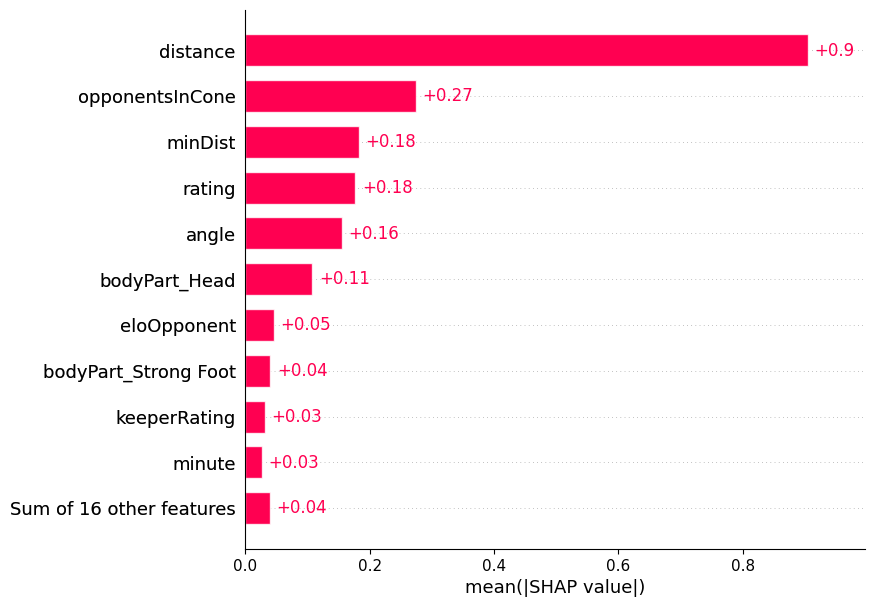

In [28]:
# usage example: model interpretation with Shapley values (bar plot)
# the bar plot displays the most important features in the model, and highlights their impact on the predictions

df = pd.read_csv('datasets/statsbomb/liga_1516.csv')
model, X_train, metrics = getPredictions(df)

explainer = shap.Explainer(model, X_train)
shapValues = explainer(X_train)

shap.plots.bar(shapValues, max_display=11)

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Precision: 0.5641
Recall: 0.125
Accuracy: 0.90484
F1: 0.20465
AUC: 0.79038
Log Loss: 0.26794
Brier: 0.07679
MAE: 0.15487


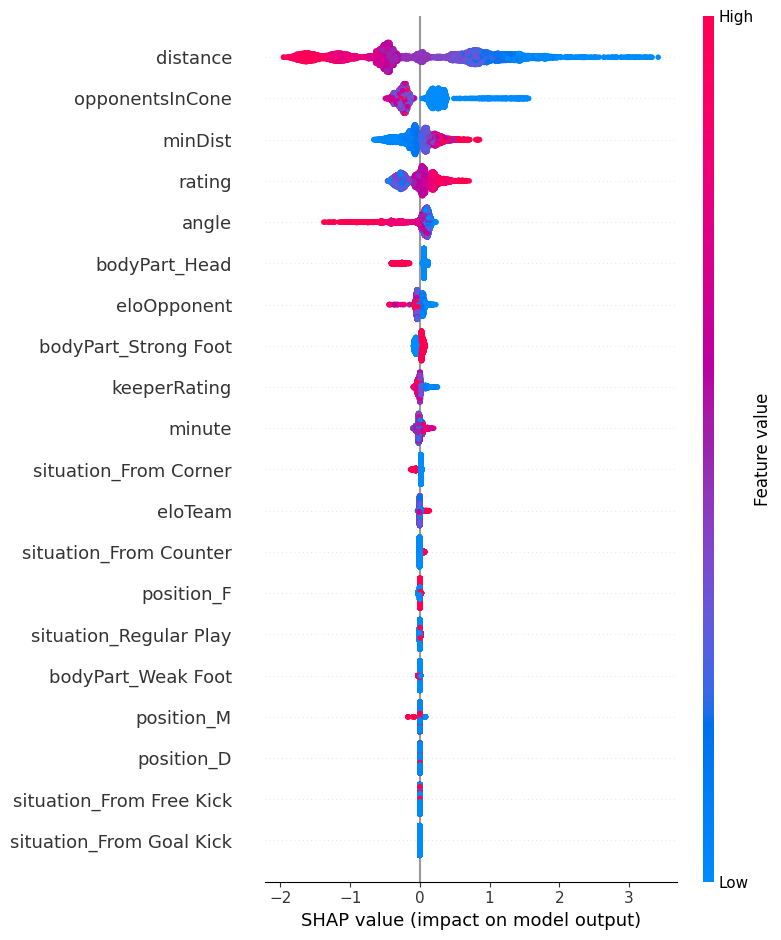

In [29]:
# usage example: model interpretation with Shapley values (summary plot)
# the summary plot visualizes the features' importance, but also their impact based on their values
# red: high values for the feature, blue: low values for the feature
# left: negative impact on the outcome, right: positive impact on the outcome

df = pd.read_csv('datasets/statsbomb/liga_1516.csv')
model, X_train, metrics = getPredictions(df)

explainer = shap.Explainer(model, X_train)
shapValues = explainer(X_train)

shap.summary_plot(shapValues, X_train)

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Precision: 0.63063
Recall: 0.10043
Accuracy: 0.90617
F1: 0.17327
AUC: 0.79649
Log Loss: 0.26288
Brier: 0.07478
MAE: 0.15178


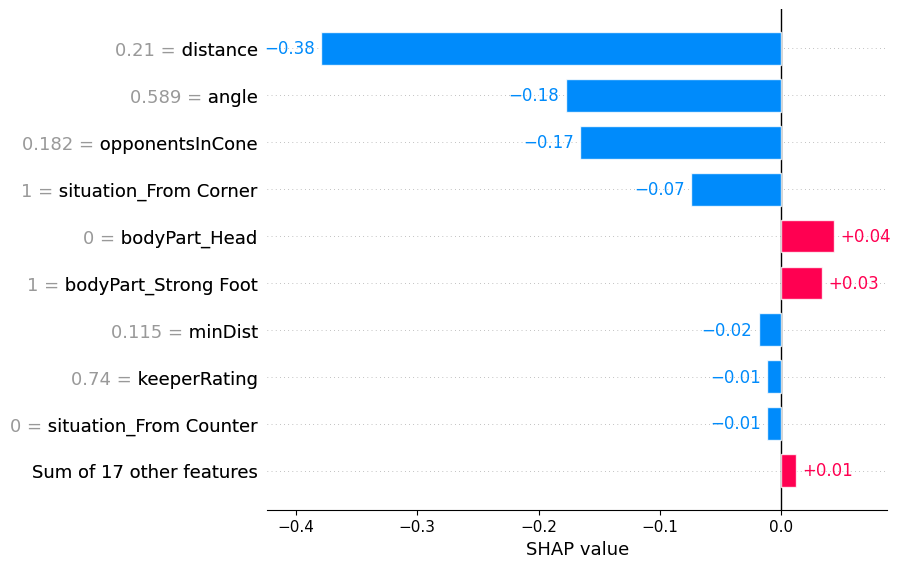

In [40]:
# usage example: explaining a single shot
df = pd.read_csv('datasets/statsbomb/top4_ITA_1516.csv')
model, X_train, metrics = getPredictions(df)

stats = predictGame(model, 'top4_ITA_1516', 'seriea_1516', 1, schedule=scheduleSb, scheduleFotmob=scheduleSs, league="ITA-Serie A", local=True)
stats['homeShots']['xg'] = round(stats['homeShots']['xg'], 2)
stats['homeShots']['xgPred'] = round(stats['homeShots']['xgPred'], 2)
stats['homeShots']['diff'] = round(stats['homeShots']['diff'], 2)
stats['awayShots']['xg'] = round(stats['awayShots']['xg'], 2)
stats['awayShots']['xgPred'] = round(stats['awayShots']['xgPred'], 2)
stats['awayShots']['diff'] = round(stats['awayShots']['diff'], 2)

stats['homeShots_clean'] = stats['homeShots_clean'].reset_index()
stats['homeShots_clean'] = stats['homeShots_clean'].drop(columns=['index'])

shot = stats['homeShots_clean'].loc[0]
explainer = shap.Explainer(model, X_train)
shapValues = explainer(shot)
shap.plots.bar(shapValues)